# Packages

In [1]:
# pip install mrcfile
import mrcfile

In [2]:
# pip install numpy
import numpy as np

In [3]:
# pip install tqdm ipywidgets
from tqdm.notebook import tqdm

In [4]:
# pip install matplotlib
import matplotlib.pyplot as plt

In [5]:
# pip install opencv-python
import cv2

In [6]:
import json

In [7]:
# pip install tensorflow

In [8]:
# pip install cryoCARE --no-deps

In [9]:
# pip install csbdeep

# Download a noisy tomogram

In [10]:
%%bash
OUTPUT_FILENAME="noisy_vol.mrc"
if test ! -f $OUTPUT_FILENAME ; then
    FILEID="1jYL6FEMeWGXO0KYlCb9udrICc2qaZLHB"
    wget --no-check-certificate 'https://docs.google.com/uc?export=download&id='$FILEID -O $OUTPUT_FILENAME 2> /dev/null
fi

In [11]:
!ls -l noisy_vol.mrc

-rw-r--r-- 1 vruiz vruiz 50001024 jun 18 06:31 noisy_vol.mrc


In [12]:
X = mrcfile.open("noisy_vol.mrc").data[:64,:256,:256]

In [13]:
X.shape

(50, 256, 256)

# Split the tomogram in even and odd axial slices

In [14]:
even_vol = X[0::2,:,:]
with mrcfile.new("even.mrc", overwrite=True) as mrc:
    mrc.set_data(even_vol)
    mrc.data

In [15]:
even_vol.shape

(25, 256, 256)

In [16]:
!ls -l "even.mrc"

-rw-r--r-- 1 vruiz vruiz 6554624 jun 18 06:46 even.mrc


In [17]:
odd_vol = X[1::2,:,:]
with mrcfile.new("odd.mrc", overwrite=True) as mrc:
    mrc.set_data(odd_vol)
    mrc.data
    mrc.data

In [18]:
odd_vol.shape

(25, 256, 256)

In [19]:
!ls -l "odd.mrc"

-rw-r--r-- 1 vruiz vruiz 6554624 jun 18 06:46 odd.mrc


# Register the even and odd tomograms by axial slices

In [20]:
farneback_params = dict(
    pyr_scale=0.5,
    levels=3,
    winsize=15,
    iterations=3,
    poly_n=5,
    poly_sigma=1.2,
    flags=0
)

In [21]:
projected_vol = np.zeros_like(odd_vol, dtype=np.float32)

In [22]:
for z in tqdm(range(even_vol.shape[0]), desc="Projecting Slices"):

    # Calculate the dense optical flow from slice_z_plus_1 to slice_z
    flow = cv2.calcOpticalFlowFarneback(even_vol[z, ...], odd_vol[z, ...], None, **farneback_params)
    
    # Create a remapping grid from the flow field
    height, width = flow.shape[:2]
    x_coords, y_coords = np.meshgrid(np.arange(width), np.arange(height))
    
    # The new map tells where each pixel in the output image should come from in the input image
    map_x = (x_coords + flow[..., 0]).astype(np.float32)
    map_y = (y_coords + flow[..., 1]).astype(np.float32)

    # Warp the *original float32 slice* using the map for maximum precision
    original_slice_to_warp = odd_vol[z , ...]
    projected_slice = cv2.remap(
        src=original_slice_to_warp,
        map1=map_x,
        map2=map_y,
        #interpolation=cv2.INTER_LINEAR,
        interpolation=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_REPLICATE # Handle edge pixels
    )
    
    # Store the result
    projected_vol[z, ...] = projected_slice

Projecting Slices:   0%|          | 0/25 [00:00<?, ?it/s]

In [23]:
projected_vol.shape

(25, 256, 256)

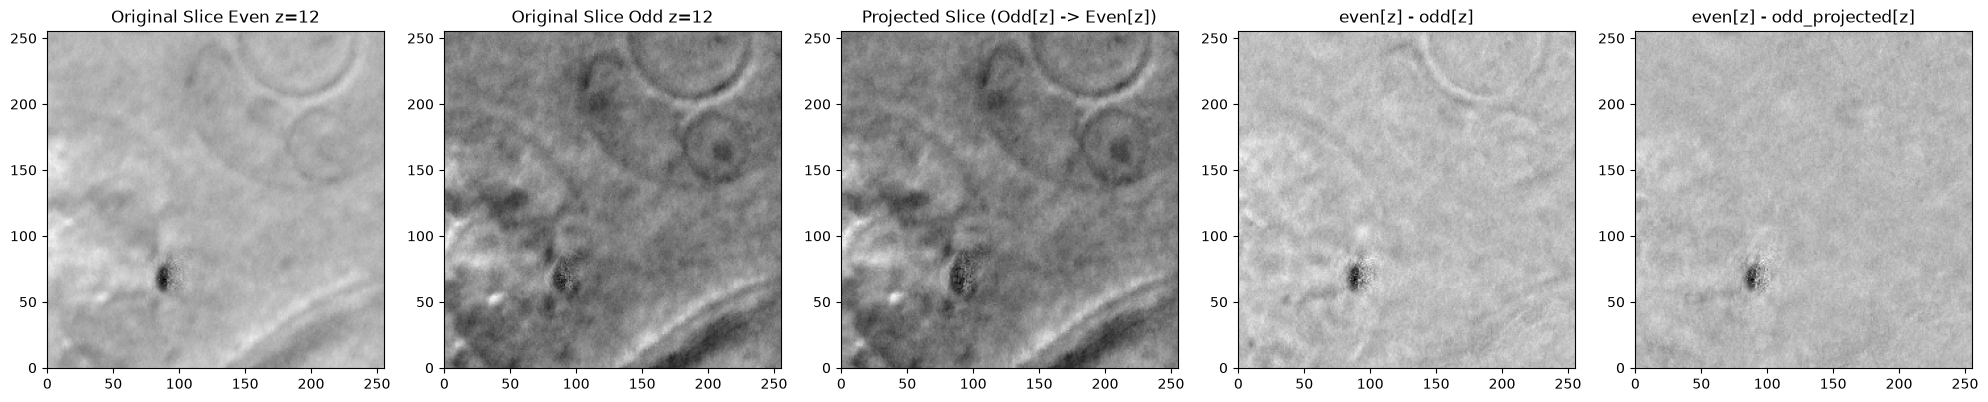

In [24]:
slice_idx = even_vol.shape[0] // 2

fig, axes = plt.subplots(1, 5, figsize=(20, 20))

im1 = axes[0].imshow(even_vol[slice_idx, ...].T, cmap='gray', origin='lower')
axes[0].set_title(f'Original Slice Even z={slice_idx}')
axes[0].grid(False)

im2 = axes[1].imshow(odd_vol[slice_idx, ...].T, cmap='gray', origin='lower')
axes[1].set_title(f'Original Slice Odd z={slice_idx}')
axes[1].grid(False)

im3 = axes[2].imshow(projected_vol[slice_idx, ...].T, cmap='gray', origin='lower')
axes[2].set_title(f'Projected Slice (Odd[z] -> Even[z])')
axes[2].grid(False)

im4 = axes[3].imshow(even_vol[slice_idx, ...].T - odd_vol[slice_idx, ...].T, cmap='gray', origin='lower')
axes[3].set_title(f'even[z] - odd[z]')
axes[3].grid(False)

im4 = axes[4].imshow(even_vol[slice_idx, ...].T - projected_vol[slice_idx, ...].T, cmap='gray', origin='lower')
axes[4].set_title(f'even[z] - odd_projected[z]')
axes[4].grid(False)

plt.tight_layout()
plt.show()

In [25]:
output_filename = 'odd_registered.mrc'
with mrcfile.new(output_filename, overwrite=True) as mrc:
    mrc.set_data(projected_vol)
    mrc.data
    mrc.data

In [26]:
!ls -l odd_registered.mrc

-rw-r--r-- 1 vruiz vruiz 6554624 jun 18 06:46 odd_registered.mrc


In [27]:
for z in tqdm(range(even_vol.shape[0]), desc="Projecting Slices"):

    # Calculate the dense optical flow from slice_z_plus_1 to slice_z
    flow = cv2.calcOpticalFlowFarneback(odd_vol[z, ...], even_vol[z, ...], None, **farneback_params)
    
    # Create a remapping grid from the flow field
    height, width = flow.shape[:2]
    x_coords, y_coords = np.meshgrid(np.arange(width), np.arange(height))
    
    # The new map tells where each pixel in the output image should come from in the input image
    map_x = (x_coords + flow[..., 0]).astype(np.float32)
    map_y = (y_coords + flow[..., 1]).astype(np.float32)

    # Warp the *original float32 slice* using the map for maximum precision
    original_slice_to_warp = even_vol[z , ...]
    projected_slice = cv2.remap(
        src=original_slice_to_warp,
        map1=map_x,
        map2=map_y,
        #interpolation=cv2.INTER_LINEAR,
        interpolation=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_REPLICATE # Handle edge pixels
    )
    
    # Store the result
    projected_vol[z, ...] = projected_slice

Projecting Slices:   0%|          | 0/25 [00:00<?, ?it/s]

In [28]:
projected_vol.shape

(25, 256, 256)

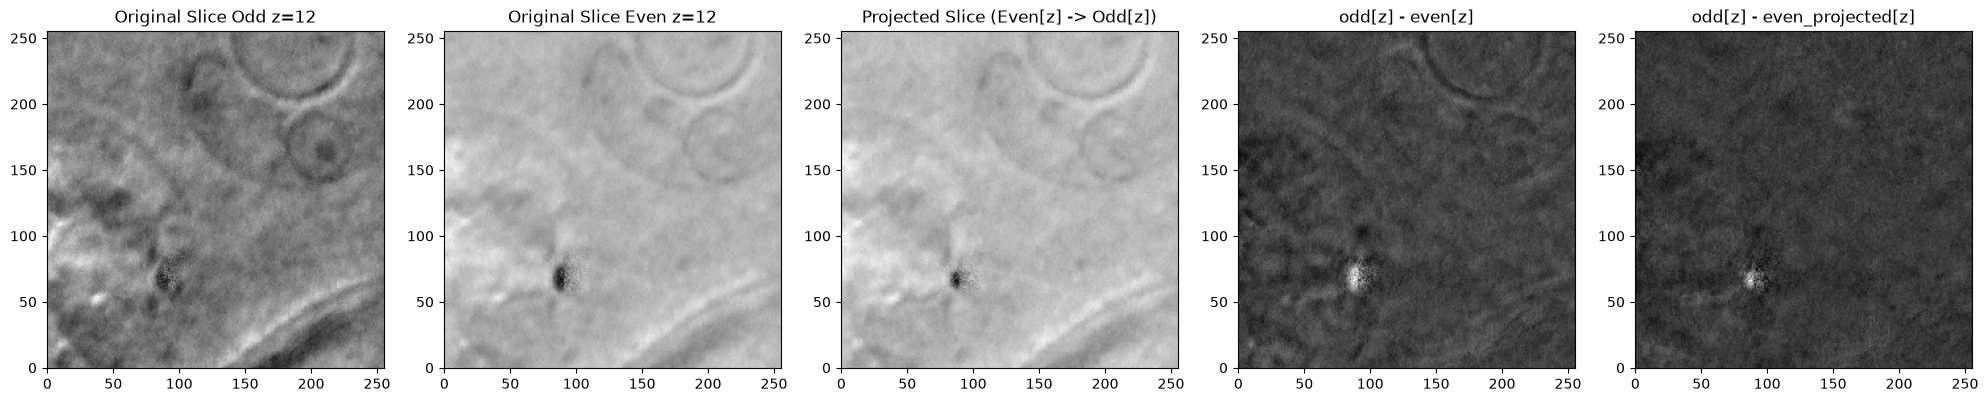

In [29]:
slice_idx = even_vol.shape[0] // 2

fig, axes = plt.subplots(1, 5, figsize=(20, 20))

im1 = axes[0].imshow(odd_vol[slice_idx, ...].T, cmap='gray', origin='lower')
axes[0].set_title(f'Original Slice Odd z={slice_idx}')
axes[0].grid(False)

im2 = axes[1].imshow(even_vol[slice_idx, ...].T, cmap='gray', origin='lower')
axes[1].set_title(f'Original Slice Even z={slice_idx}')
axes[1].grid(False)

im3 = axes[2].imshow(projected_vol[slice_idx, ...].T, cmap='gray', origin='lower')
axes[2].set_title(f'Projected Slice (Even[z] -> Odd[z])')
axes[2].grid(False)

im4 = axes[3].imshow(odd_vol[slice_idx, ...].T - even_vol[slice_idx, ...].T, cmap='gray', origin='lower')
axes[3].set_title(f'odd[z] - even[z]')
axes[3].grid(False)

im4 = axes[4].imshow(odd_vol[slice_idx, ...].T - projected_vol[slice_idx, ...].T, cmap='gray', origin='lower')
axes[4].set_title(f'odd[z] - even_projected[z]')
axes[4].grid(False)

plt.tight_layout()
plt.show()

In [30]:
output_filename = 'even_registered.mrc'
print("Writing", output_filename)

with mrcfile.new(output_filename, overwrite=True) as mrc:
    mrc.set_data(projected_vol)
    mrc.data

Writing even_registered.mrc


In [31]:
!ls -l even_registered.mrc

-rw-r--r-- 1 vruiz vruiz 6554624 jun 18 06:46 even_registered.mrc


# Denoising

In [32]:
_ = {
    "even": ["even.mrc", "even_registered.mrc"],
    "odd": ["odd_registered.mrc", "odd.mrc"],
    "mask": [""],
    "patch_shape": [8, 8, 8], # <- Be careful here: in this example the tomogram is very small and the patch shape must be also small
    "num_slices": 800,
    "split": 0.9,
    "tilt_axis": "Y",
    "n_normalization_samples": 200,
    "path": "./data",
    "overwrite": "True"  
}

with open("train_data_config.json", 'w') as f:
    json.dump(_, f, indent=4)

In [33]:
%%bash
cryoCARE_extract_train_data.py --conf train_data_config.json

I0000 00:00:1781757997.092060   19804 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781757997.092246   19804 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781757997.134088   19804 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781757998.456404   19804 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Computing normalization parameters:


100%|██████████| 200/200 [00:00<00:00, 12579.26it/s]


In [34]:
%%writefile train_config.json
{
  "train_data": "./data",
  "epochs": 50,
  "steps_per_epoch": 200,
  "batch_size": 16,
  "unet_kern_size": 3,
  "unet_n_depth": 3,
  "unet_n_first": 16,
  "learning_rate": 0.0004,
  "model_name": "model",
  "path": "./",
  "gpu_id": [0]
}

Writing train_config.json


In [ ]:
%%bash
cryoCARE_train.py --conf train_config.json

I0000 00:00:1781758000.293095   19853 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781758000.293283   19853 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781758000.334547   19853 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781758001.457235   19853 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Looking for GPU with ID: 0
0 1
1 8
2 8
3 8
4 1
Epoch 1/50


E0000 00:00:1781758004.859001   19853 util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.2504 - mae: 0.3441 - mse: 0.2504

/home/vruiz/envs/N2N-REO/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.2447 - mae: 0.3386 - mse: 0.2447 - val_loss: 0.1224 - val_mae: 0.2746 - val_mse: 0.1224 - learning_rate: 4.0000e-04
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.2095 - mae: 0.3147 - mse: 0.2095 - val_loss: 0.1156 - val_mae: 0.2672 - val_mse: 0.1156 - learning_rate: 4.0000e-04
Epoch 3/50
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.2109 - mae: 0.3134 - mse: 0.2109

W0000 00:00:1781758021.025969   20405 local_rendezvous.cc:412] Local rendezvous is aborting with status: CANCELLED: GetNextFromShard was cancelled
	 [[{{node MultiDeviceIteratorGetNextFromShard}}]]


200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.2066 - mae: 0.3125 - mse: 0.2066 - val_loss: 0.1202 - val_mae: 0.2720 - val_mse: 0.1202 - learning_rate: 4.0000e-04
Epoch 4/50
127/200 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.2096 - mae: 0.3092 - mse: 0.2096

In [ ]:
_ = {
    "path": "./model.tar.gz",
    "even": ["noisy_vol.mrc"], 
    "odd": ["noisy_vol.mrc"],
    "n_tiles": [1,1,1],
    "output": "denoised_vol",
    "overwrite": "True",
    "gpu_id": [0]
}

with open("predict_config.json", 'w') as f:
    json.dump(_, f, indent=4)

In [ ]:
%%bash
cryoCARE_predict.py --conf predict_config.json || true

In [ ]:
!ls -l denoised_vol/noisy_vol.mrc

In [ ]:
Y = mrcfile.read("denoised_vol/noisy_vol.mrc")

In [ ]:
X.shape

In [ ]:
Y.shape

In [ ]:
slice_idx = X.shape[0] // 2

fig, axes = plt.subplots(1, 2, figsize=(15, 15))

# Plot the original slice z
im1 = axes[0].imshow(X[slice_idx, :, :].T, cmap='gray', origin='lower')
axes[0].set_title(f'Original Slice Z={slice_idx}')
axes[0].grid(False)

# Plot the original slice z+1
im2 = axes[1].imshow(Y[slice_idx, :, :].T, cmap='gray', origin='lower')
axes[1].set_title(f'N2N-Odd-Even-Registered Denoised Slice Z={slice_idx}')
axes[1].grid(False)

plt.tight_layout()
plt.show()